### Hyper-parameters

In [1]:
import os
import pandas as pd
import pickle
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

import ast

In [19]:
actor_num = 3 # LDA 진행하고자 하는 actor 번호; 0~4
topic_num_ = 3 # topic 개수

In [3]:
df = pd.read_csv(f'../clustering/results_clustering/ActorClustering_kmeans_kure_128_k5_bigram.csv', encoding='utf-8-sig')

print(len(df))
df.head()

58314


,Unnamed: 0,출처,키워드,제목,내용,작성일,링크,token,vector,cluster,bigram
0,0,네이버카페_레몬테라스,육아일기,돌아기 전집 뭐가 좋나요,이제 돌 지나서 돌 전집 사주려고 하는데요 프뢰벨 영아다중이랑 말하기 이렇게만 있거...,2024-12-31,https://cafe.naver.com/f-e/cafes/10298136/arti...,"['돌', '지나다', '돌', '전', '집', '사다', '프뢰벨', '영아',...",[ 8.4111039e-03 -2.8329432e-02 1.0804157e+01 ...,1,"['돌_지나다', '지나다_돌', '돌_전', '전_집', '집_사다', '사다_프..."
1,1,블로그_네이버,임신,하지불안증후군 증상 치료 원인 완치가능성,하지불안증후군 다리에서 불쾌한 감각을 느끼고 이를 해소하기 위하여 움직이고 싶은 강...,2024-12-31,https://blog.naver.com/rkfkadk04/223710185729,"['하지불안 증후군', '다리', '감각', '느끼다', '해소', '위하다', '...",[ 0.02329755 0.33748412 5.701536 10.034008...,2,"['하지불안 증후군_다리', '다리_감각', '감각_느끼다', '느끼다_해소', '..."
2,2,네이버카페_맘이베베,육아질문방,주차 튼살크림 추천해주세요,튼살크림이 종류가 엄청 많더라구요 그래서 알아보고 있는데 종류가 너무 다양해서 고민...,2024-12-31,https://cafe.naver.com/f-e/cafes/29434212/arti...,"['트다', '살', '크림', '종류', '많다', '알아보다', '종류', '다...",[4.2346669e-03 1.8436287e-02 9.1599712e+00 8.8...,4,"['트다_살', '살_크림', '크림_종류', '종류_많다', '많다_알아보다', ..."
3,3,블로그_네이버,육아,셀프 산후조리 시작 완모 산후도우미 불러야할까,셀프 산후조리 시작 완모 산후도우미 불러야할까 오늘 입원 마지막 날 우리는 셋이 되...,2024-12-31,https://blog.naver.com/today_h/223711009087,"['셀프', '산후', '조리', '시작', '완', '산후', '도우미', '부르...",[0.02605256 0.21050377 7.150107 9.429928 1...,2,"['셀프_산후', '산후_조리', '조리_시작', '시작_완', '완_산후', '산..."
4,4,네이버카페_맘이베베,육아질문방,입덧약 처방 받아야 할지 좀 참아볼지 고민입니다,둘째는 입덧이 다르네요 음식을 먹고난 직후가 제일 심하고 냄새에 엄청 예민해지고 체...,2024-12-31,https://cafe.naver.com/f-e/cafes/29434212/arti...,"['입덧', '다르다', '음식', '먹다', '직후', '심하다', '냄새', '...",[2.0861698e-03 7.1943946e-02 8.5836906e+00 1.0...,0,"['입덧_다르다', '다르다_음식', '음식_먹다', '먹다_직후', '직후_심하다..."


In [4]:
df['tokenized'] = df['bigram']
df.head()

,Unnamed: 0,출처,키워드,제목,내용,작성일,링크,token,vector,cluster,bigram,tokenized
0,0,네이버카페_레몬테라스,육아일기,돌아기 전집 뭐가 좋나요,이제 돌 지나서 돌 전집 사주려고 하는데요 프뢰벨 영아다중이랑 말하기 이렇게만 있거...,2024-12-31,https://cafe.naver.com/f-e/cafes/10298136/arti...,"['돌', '지나다', '돌', '전', '집', '사다', '프뢰벨', '영아',...",[ 8.4111039e-03 -2.8329432e-02 1.0804157e+01 ...,1,"['돌_지나다', '지나다_돌', '돌_전', '전_집', '집_사다', '사다_프...","['돌_지나다', '지나다_돌', '돌_전', '전_집', '집_사다', '사다_프..."
1,1,블로그_네이버,임신,하지불안증후군 증상 치료 원인 완치가능성,하지불안증후군 다리에서 불쾌한 감각을 느끼고 이를 해소하기 위하여 움직이고 싶은 강...,2024-12-31,https://blog.naver.com/rkfkadk04/223710185729,"['하지불안 증후군', '다리', '감각', '느끼다', '해소', '위하다', '...",[ 0.02329755 0.33748412 5.701536 10.034008...,2,"['하지불안 증후군_다리', '다리_감각', '감각_느끼다', '느끼다_해소', '...","['하지불안 증후군_다리', '다리_감각', '감각_느끼다', '느끼다_해소', '..."
2,2,네이버카페_맘이베베,육아질문방,주차 튼살크림 추천해주세요,튼살크림이 종류가 엄청 많더라구요 그래서 알아보고 있는데 종류가 너무 다양해서 고민...,2024-12-31,https://cafe.naver.com/f-e/cafes/29434212/arti...,"['트다', '살', '크림', '종류', '많다', '알아보다', '종류', '다...",[4.2346669e-03 1.8436287e-02 9.1599712e+00 8.8...,4,"['트다_살', '살_크림', '크림_종류', '종류_많다', '많다_알아보다', ...","['트다_살', '살_크림', '크림_종류', '종류_많다', '많다_알아보다', ..."
3,3,블로그_네이버,육아,셀프 산후조리 시작 완모 산후도우미 불러야할까,셀프 산후조리 시작 완모 산후도우미 불러야할까 오늘 입원 마지막 날 우리는 셋이 되...,2024-12-31,https://blog.naver.com/today_h/223711009087,"['셀프', '산후', '조리', '시작', '완', '산후', '도우미', '부르...",[0.02605256 0.21050377 7.150107 9.429928 1...,2,"['셀프_산후', '산후_조리', '조리_시작', '시작_완', '완_산후', '산...","['셀프_산후', '산후_조리', '조리_시작', '시작_완', '완_산후', '산..."
4,4,네이버카페_맘이베베,육아질문방,입덧약 처방 받아야 할지 좀 참아볼지 고민입니다,둘째는 입덧이 다르네요 음식을 먹고난 직후가 제일 심하고 냄새에 엄청 예민해지고 체...,2024-12-31,https://cafe.naver.com/f-e/cafes/29434212/arti...,"['입덧', '다르다', '음식', '먹다', '직후', '심하다', '냄새', '...",[2.0861698e-03 7.1943946e-02 8.5836906e+00 1.0...,0,"['입덧_다르다', '다르다_음식', '음식_먹다', '먹다_직후', '직후_심하다...","['입덧_다르다', '다르다_음식', '음식_먹다', '먹다_직후', '직후_심하다..."


# ◆ 1. LDA를 위한 데이터 전처리
* 1.1. 전체 단어의 사전 만들고 각 문서에 매칭하기
    > 단어들이 문서에 얼마나 위치해 있는지 분포를 파악해야하기 때문에 분석할 전체 데이터 대상으로
    사용된 단어의 사전을 생성해야한다,


In [5]:
import gensim
from gensim import corpora, models
from gensim.corpora import Dictionary

### 1.1 전체 단어의 사전 만들고 각 문서에 매칭하기

In [6]:
# cluster 0
df_cluster0 = df[df['cluster'] == actor_num]
print(len(df_cluster0))
df_cluster0.head()

10059


,Unnamed: 0,출처,키워드,제목,내용,작성일,링크,token,vector,cluster,bigram,tokenized
6,6,네이버카페_레몬테라스,육아일기,육퇴하고싶어요,개월 첫째와 개월 둘째가 있는 집안입니다 둘째는 눕히자마자 자는데 개월 언니는 안자...,2024-12-31,https://cafe.naver.com/f-e/cafes/10298136/arti...,"['집안', '눕히다', '자다', '언니', '자다', '쉬다']",[ 3.5150992e-03 -1.6197544e-03 1.0032904e+01 ...,3,"['집안_눕히다', '눕히다_자다', '자다_언니', '언니_자다', '자다_쉬다']","['집안_눕히다', '눕히다_자다', '자다_언니', '언니_자다', '자다_쉬다']"
25,25,네이버카페_맘이베베,육아질문방,간식뭐드세요,주인데 아가가 급격히 배둘레가 커졌다고 과자 빵 떡 먹지말고 밥도 쌀밥대신 현미밥 ...,2024-12-30,https://cafe.naver.com/f-e/cafes/29434212/arti...,"['주', '아가', '배', '둘레', '커지다', '과자', '빵', '떡', ...",[1.3834463e-03 9.4724670e-03 9.5459032e+00 8.3...,3,"['주_아가', '아가_배', '배_둘레', '둘레_커지다', '커지다_과자', '...","['주_아가', '아가_배', '배_둘레', '둘레_커지다', '커지다_과자', '..."
56,56,네이버카페_맘이베베,육아질문방,개월 아기 짜증 저만 이런가요,개월 아기 일 를 키우고 있는데요 정말 너무너무너무너무 너 무 짜증이 늘고 고집이 ...,2024-12-28,https://cafe.naver.com/f-e/cafes/29434212/arti...,"['아기', '르', '키우다', '짜증', '늘다', '고집', '세다', '힘들...",[ 8.0771383e-04 -5.7248208e-03 9.9244299e+00 ...,3,"['아기_르', '르_키우다', '키우다_짜증', '짜증_늘다', '늘다_고집', ...","['아기_르', '르_키우다', '키우다_짜증', '짜증_늘다', '늘다_고집', ..."
127,127,블로그_네이버,육아,아기 수면교육 없이 눕잠 향해 가기 누워 잠들기,아기 누워 잠들기 눕잠 엄마들의 로망이죠 하지만 현실은 밤샘 수유와 토닥임의 연속 ...,2024-12-24,https://blog.naver.com/julieemom/223695041089,"['아기', '잠들다', '엄마', '로망', '현실', '밤샘', '수유', '토...",[ 1.3570663e-03 -1.3136398e-03 1.0023156e+01 ...,3,"['아기_잠들다', '잠들다_엄마', '엄마_로망', '로망_현실', '현실_밤샘'...","['아기_잠들다', '잠들다_엄마', '엄마_로망', '로망_현실', '현실_밤샘'..."
169,169,네이버카페_레몬테라스,육아일기,아이 면역관리 개월차,초딩남아 요즘 면역관리 하고 있어요 워낙 비실비실해서 늘 걱정이였는데 그래도 요즘은...,2024-12-23,https://cafe.naver.com/f-e/cafes/10298136/arti...,"['초딩', '남아', '요즘', '면역', '관리', '걱정', '요즘', '잔병...",[4.0737321e-03 3.7136331e-02 8.8529272e+00 9.4...,3,"['초딩_남아', '남아_요즘', '요즘_면역', '면역_관리', '관리_걱정', ...","['초딩_남아', '남아_요즘', '요즘_면역', '면역_관리', '관리_걱정', ..."


In [7]:
# 1. 문자열을 실제 리스트로 변환해주는 함수
def parse_tokens(text):
    if isinstance(text, str):
        try:
            return ast.literal_eval(text)
        except (ValueError, SyntaxError):
            # 만약 "단어1 단어2" 형태의 단순 띄어쓰기 문자열이라면 split() 적용
            return text.split()
    return text

# 2. 'tokenized' 컬럼에 함수 적용 후 리스트로 변환
all_documents = df_cluster0['tokenized'].apply(parse_tokens).tolist()

# 3. 사전(Dictionary) 생성
dictionary = Dictionary(all_documents)

# 결과 확인
print(f"단어장 생성 완료! 총 단어 개수: {len(dictionary)}")
dictionary.token2id  # 필요 시 주석 해제하여 확인

단어장 생성 완료! 총 단어 개수: 143846


{'눕히다_자다': 0,
 '언니_자다': 1,
 '자다_쉬다': 2,
 '자다_언니': 3,
 '집안_눕히다': 4,
 '간식_드세다': 5,
 '과일_식당': 6,
 '과자_빵': 7,
 '나오다_후식': 8,
 '대신_현미': 9,
 '둘레_커지다': 10,
 '드세다_슬프다': 11,
 '떡_먹다': 12,
 '르_밥': 13,
 '마르다_체형': 14,
 '먹다_간식': 15,
 '먹다_과일': 16,
 '먹다_르': 17,
 '먹다_마르다': 18,
 '먹다_먹다': 19,
 '먹다_밥': 20,
 '먹다_배고프다': 21,
 '밥_먹다': 22,
 '밥_쌀밥': 23,
 '배_둘레': 24,
 '배고프다_과자': 25,
 '배고프다_먹다': 26,
 '빵_떡': 27,
 '빵_먹다': 28,
 '식당_나오다': 29,
 '쌀밥_대신': 30,
 '아가_배': 31,
 '주_아가': 32,
 '체형_밥': 33,
 '커지다_과자': 34,
 '현미_밥': 35,
 '후식_먹다': 36,
 '고집_세다': 37,
 '극_달하다': 38,
 '글_남기다': 39,
 '남기다_정도': 40,
 '낮잠_밤잠': 41,
 '내다_눕히다': 42,
 '내다_울다': 43,
 '놀다_짜증': 44,
 '눕히다_짜증': 45,
 '늘다_고집': 46,
 '달하다_집': 47,
 '로션_바르다': 48,
 '루트_분유': 49,
 '르_키우다': 50,
 '먹다_분유': 51,
 '먹다_짜증': 52,
 '바르다_짜증': 53,
 '밤잠_사이': 54,
 '분유_먹다': 55,
 '사이_짜증': 56,
 '세다_힘들다': 57,
 '솔_루트': 58,
 '스미다_얼': 59,
 '시_짜증': 60,
 '시작_주': 61,
 '아가_이유식': 62,
 '아가_집': 63,
 '아기_르': 64,
 '앱_솔': 65,
 '얼_로션': 66,
 '울다_낮잠': 67,
 '이유식_시작': 68,
 '정도_앱': 69,
 '주_먹다': 70,
 '죽다_글': 71,
 '집_

In [8]:
corpus = []
for doc in all_documents:
    corpus.append(dictionary.doc2bow(doc))
    
corpus

[[(0, 1), (1, 1), (2, 1), (3, 1), (4, 1)],
 [(5, 1),
  (6, 1),
  (7, 2),
  (8, 1),
  (9, 1),
  (10, 1),
  (11, 1),
  (12, 1),
  (13, 1),
  (14, 1),
  (15, 1),
  (16, 1),
  (17, 1),
  (18, 1),
  (19, 1),
  (20, 2),
  (21, 2),
  (22, 4),
  (23, 1),
  (24, 1),
  (25, 1),
  (26, 1),
  (27, 1),
  (28, 1),
  (29, 1),
  (30, 1),
  (31, 1),
  (32, 1),
  (33, 1),
  (34, 1),
  (35, 1),
  (36, 1)],
 [(37, 1),
  (38, 1),
  (39, 1),
  (40, 1),
  (41, 1),
  (42, 1),
  (43, 1),
  (44, 1),
  (45, 1),
  (46, 1),
  (47, 1),
  (48, 1),
  (49, 1),
  (50, 1),
  (51, 1),
  (52, 1),
  (53, 1),
  (54, 1),
  (55, 2),
  (56, 1),
  (57, 1),
  (58, 1),
  (59, 1),
  (60, 1),
  (61, 1),
  (62, 1),
  (63, 1),
  (64, 1),
  (65, 1),
  (66, 1),
  (67, 1),
  (68, 1),
  (69, 1),
  (70, 1),
  (71, 1),
  (72, 2),
  (73, 1),
  (74, 2),
  (75, 1),
  (76, 1),
  (77, 1),
  (78, 1),
  (79, 1),
  (80, 1),
  (81, 1)],
 [(82, 1),
  (83, 1),
  (84, 1),
  (85, 1),
  (86, 1),
  (87, 1),
  (88, 1),
  (89, 1),
  (90, 1),
  (91, 2),
  (

# ◆ 2. LDA모델 만들기
* 2.1 LDA 기본 모델 만들기
* 2.2 LDA 토픽개수 선정
* 2.3 선정한 토픽 개수로 Action 넘버 매칭

### 2.1 LDA 기본 모델 만들기

In [9]:
# topic_num = 4 # 3 
# ldamodel = gensim.models.ldamodel.LdaModel(corpus,
#                                            num_topics= topic_num,
#                                            id2word= dictionary,
#                                            passes= 20,
#                                            iterations= 50,
#                                            random_state= 42)

In [10]:
# ldamodel.print_topics(num_words= 10)

In [11]:
# for i in range(int(len(corpus)/100)):
#     print(ldamodel.get_document_topics(corpus[i]))

### 2.2 LDA 토픽 수 선정
* cohearence & perplexcity

In [12]:
from gensim.models import CoherenceModel # coherence 모델 라이브러리
import matplotlib.pyplot as plt # 그래프 그리기
import numpy as np

> 2.2.1 Perplexity 그래프 만들기

In [13]:
perplexity_values = []

for i in range(2, 10):
    ldamodel = gensim.models.ldamodel.LdaModel(corpus,
                                               num_topics= i,
                                               id2word= dictionary)
    perplexity_v = np.exp(-ldamodel.log_perplexity(corpus))
    perplexity_values.append(perplexity_v)

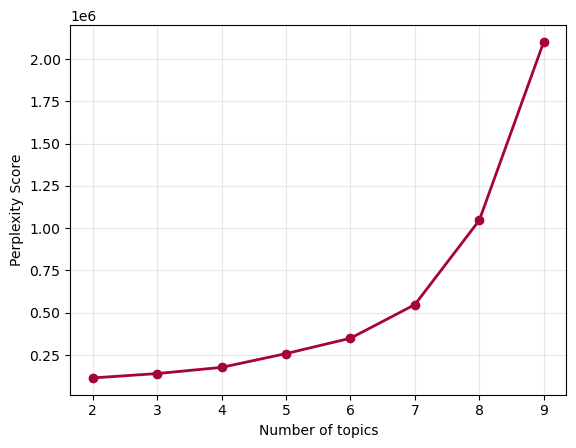

In [14]:
x = range(2, 10)

plt.plot(
    x,
    perplexity_values,
    marker='o',          # 원형 점
    color='#A50534',     # 지정한 색상
    linewidth=2
)

plt.xlabel('Number of topics')
plt.ylabel('Perplexity Score')
plt.grid(alpha=0.3)      # (선택) 가독성용
plt.gca().set_facecolor('none')
plt.gcf().set_facecolor('none')
plt.savefig(f'./results/LDA_Actor{actor_num}_action_cluster_perplexity_plot.png', dpi=300, transparent=True)
plt.show()

In [15]:
# perplexity 그래프 raw 데이터 저장
result0 = pd.DataFrame([x, perplexity_values]).T
result0.columns = ['n_cluster', 'perplexity_values']
result0.to_excel(f'./results/LDA_Actor{actor_num}_action_cluster_perplexity.xlsx', index=False)

> 2.2.1 Coherence 그래프 만들기

In [16]:
coherence_values = []
top_n = 3

for i in tqdm(range(2,10)):
    ldamodel = gensim.models.ldamodel.LdaModel(corpus,
                                               num_topics= i,
                                               id2word= dictionary)
    coherence_model = CoherenceModel(model= ldamodel,
                                 texts= all_documents,
                                 dictionary= dictionary,
                                 topn= top_n)
    
    coherence_score = coherence_model.get_coherence()
    coherence_values.append(coherence_score)

100%|██████████| 8/8 [01:05<00:00,  8.21s/it]


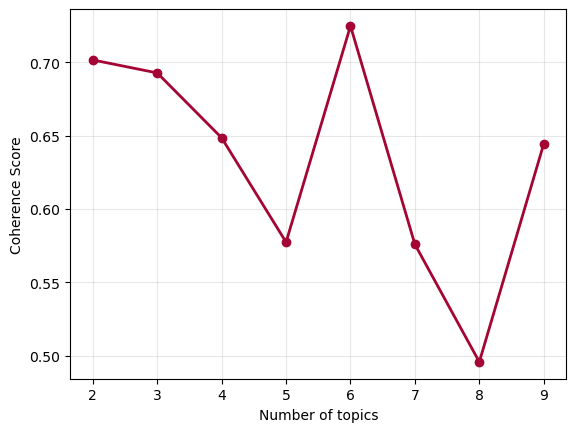

In [17]:
x = range(2, 10)

plt.plot(
    x,
    coherence_values,
    marker='o',          # 원형 점
    color='#A50534',     # 지정한 색상
    linewidth=2
)

plt.xlabel('Number of topics')
plt.ylabel('Coherence Score')
plt.grid(alpha=0.3)      # (선택) 가독성용
plt.gca().set_facecolor('none')
plt.gcf().set_facecolor('none')
plt.savefig(f'./results/LDA_Actor{actor_num}_action_cluster_coherance_plot.png', dpi=300, transparent=True)
plt.show()

In [18]:
# Coherance 그래프 raw 데이터 저장
result0 = pd.DataFrame([x, coherence_values]).T
result0.columns = ['n_cluster', 'coherence_values']
result0.to_excel(f'./results/LDA_Actor{actor_num}_action_cluster_coherence.xlsx', index=False)

### 2.3 선정한 토픽 개수로 Action 넘버 매칭

In [20]:
topic_num = topic_num_ # 3

ldamodel = gensim.models.ldamodel.LdaModel(corpus,
                                           num_topics= topic_num,
                                           id2word= dictionary,
                                           passes= 20,
                                           iterations= 50,
                                           random_state= 42)

In [21]:
ldamodel.get_document_topics(corpus)[2]

[(0, 0.08893141), (1, 0.90309465)]

In [22]:
action_align = []

for doc in tqdm(ldamodel.get_document_topics(corpus)):
    label = []
    value = []
    
    for score in doc:
        label.append(score[0])
        value.append(score[1])
        
    max_index = np.argmax(value)
    action_n = label[max_index]
    action_align.append(action_n)
    

100%|██████████| 10059/10059 [00:01<00:00, 9186.77it/s]


In [23]:
df_cluster0['action_cluster'] = action_align
df_cluster0.head()

,Unnamed: 0,출처,키워드,제목,내용,작성일,링크,token,vector,cluster,bigram,tokenized,action_cluster
6,6,네이버카페_레몬테라스,육아일기,육퇴하고싶어요,개월 첫째와 개월 둘째가 있는 집안입니다 둘째는 눕히자마자 자는데 개월 언니는 안자...,2024-12-31,https://cafe.naver.com/f-e/cafes/10298136/arti...,"['집안', '눕히다', '자다', '언니', '자다', '쉬다']",[ 3.5150992e-03 -1.6197544e-03 1.0032904e+01 ...,3,"['집안_눕히다', '눕히다_자다', '자다_언니', '언니_자다', '자다_쉬다']","['집안_눕히다', '눕히다_자다', '자다_언니', '언니_자다', '자다_쉬다']",0
25,25,네이버카페_맘이베베,육아질문방,간식뭐드세요,주인데 아가가 급격히 배둘레가 커졌다고 과자 빵 떡 먹지말고 밥도 쌀밥대신 현미밥 ...,2024-12-30,https://cafe.naver.com/f-e/cafes/29434212/arti...,"['주', '아가', '배', '둘레', '커지다', '과자', '빵', '떡', ...",[1.3834463e-03 9.4724670e-03 9.5459032e+00 8.3...,3,"['주_아가', '아가_배', '배_둘레', '둘레_커지다', '커지다_과자', '...","['주_아가', '아가_배', '배_둘레', '둘레_커지다', '커지다_과자', '...",1
56,56,네이버카페_맘이베베,육아질문방,개월 아기 짜증 저만 이런가요,개월 아기 일 를 키우고 있는데요 정말 너무너무너무너무 너 무 짜증이 늘고 고집이 ...,2024-12-28,https://cafe.naver.com/f-e/cafes/29434212/arti...,"['아기', '르', '키우다', '짜증', '늘다', '고집', '세다', '힘들...",[ 8.0771383e-04 -5.7248208e-03 9.9244299e+00 ...,3,"['아기_르', '르_키우다', '키우다_짜증', '짜증_늘다', '늘다_고집', ...","['아기_르', '르_키우다', '키우다_짜증', '짜증_늘다', '늘다_고집', ...",1
127,127,블로그_네이버,육아,아기 수면교육 없이 눕잠 향해 가기 누워 잠들기,아기 누워 잠들기 눕잠 엄마들의 로망이죠 하지만 현실은 밤샘 수유와 토닥임의 연속 ...,2024-12-24,https://blog.naver.com/julieemom/223695041089,"['아기', '잠들다', '엄마', '로망', '현실', '밤샘', '수유', '토...",[ 1.3570663e-03 -1.3136398e-03 1.0023156e+01 ...,3,"['아기_잠들다', '잠들다_엄마', '엄마_로망', '로망_현실', '현실_밤샘'...","['아기_잠들다', '잠들다_엄마', '엄마_로망', '로망_현실', '현실_밤샘'...",0
169,169,네이버카페_레몬테라스,육아일기,아이 면역관리 개월차,초딩남아 요즘 면역관리 하고 있어요 워낙 비실비실해서 늘 걱정이였는데 그래도 요즘은...,2024-12-23,https://cafe.naver.com/f-e/cafes/10298136/arti...,"['초딩', '남아', '요즘', '면역', '관리', '걱정', '요즘', '잔병...",[4.0737321e-03 3.7136331e-02 8.8529272e+00 9.4...,3,"['초딩_남아', '남아_요즘', '요즘_면역', '면역_관리', '관리_걱정', ...","['초딩_남아', '남아_요즘', '요즘_면역', '면역_관리', '관리_걱정', ...",2


In [24]:
df_cluster0['action_cluster'].value_counts()

action_cluster
0    4195
1    3689
2    2175
Name: count, dtype: int64

# ◆ 3. LDA 시각화 (LDAvis)


In [25]:
# !pip install pyLDAvis

In [26]:
#경고무시
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

#LDA 시각화 라이브러리
import pyLDAvis.gensim_models as gensimvis
import pyLDAvis

In [27]:
prepared_data = gensimvis.prepare(ldamodel, corpus, dictionary)
# pyLDAvis.save_html(prepared_data, f'{output_path}/ldavis_Actor_{actor_num}.html')
pyLDAvis.save_html(prepared_data, f'./results/LDA_Actor{actor_num}_ldavis.html')
# pyLDAvis.display(prepared_data)

In [28]:
pyLDAvis.display(prepared_data)

# ◆ 4. LDA 분석을 위한 후작업
* LDAvis와 LDA모델의 토픽 넘버 매칭
* LDAvis 결과와 LDA모델의 결과를 보고 직접 매칭해야한다.

In [29]:
topics = ldamodel.show_topics(num_topics= -1, # - 1 은 다 가져오라는것
                              formatted= True,
                              )

for topic_id, topic_desc in topics :
    print(f"Topic ID : {topic_id}, Description : {topic_desc}")

Topic ID : 0, Description : 0.010*"잠_자다" + 0.005*"밤_잠" + 0.004*"새벽_수유" + 0.004*"낮잠_자다" + 0.003*"분리_수면" + 0.003*"시_시" + 0.003*"자다_깨다" + 0.003*"자다_자다" + 0.003*"새벽_깨다" + 0.003*"수면_교육"
Topic ID : 1, Description : 0.005*"분유_먹다" + 0.004*"먹다_먹다" + 0.004*"밥_먹다" + 0.003*"빨대_컵" + 0.003*"이유식_먹다" + 0.003*"더블_하트" + 0.002*"정도_먹다" + 0.002*"유_축" + 0.002*"먹다_아기" + 0.002*"주다_먹다"
Topic ID : 2, Description : 0.004*"압_밀" + 0.003*"조리_원" + 0.002*"분유_바꾸다" + 0.002*"발_락" + 0.002*"이유식_시작" + 0.002*"먹이다_먹이다" + 0.002*"부탁_드리다" + 0.001*"유산균_먹이다" + 0.001*"수_필요" + 0.001*"퐁_당"


In [36]:
# 모델 LDAvis
# lda   ldavis
# 0     3
# 1     1
# 2     2
lda_ldavis_map = {0:'1',
                  1:'2',
                  2:'3',
                  }

In [37]:
new_action_topic = []

for i in df_cluster0['action_cluster'] :
    n = lda_ldavis_map[i]
    
    # if i == 0 :
    #     n = 3
    # elif i == 1 : 
    #     n = 1
    # elif i == 2 :
    #     n = 2
    # else : 
    #     n = 1
    new_action_topic.append(n)

KeyError: '3'

In [ ]:
df_cluster0['action_cluster'] = new_action_topic
df_cluster0.head()

,Unnamed: 0,출처,키워드,제목,내용,작성일,링크,token,vector,cluster,bigram,tokenized,action_cluster
6,6,네이버카페_레몬테라스,육아일기,육퇴하고싶어요,개월 첫째와 개월 둘째가 있는 집안입니다 둘째는 눕히자마자 자는데 개월 언니는 안자...,2024-12-31,https://cafe.naver.com/f-e/cafes/10298136/arti...,"['집안', '눕히다', '자다', '언니', '자다', '쉬다']",[ 3.5150992e-03 -1.6197544e-03 1.0032904e+01 ...,3,"['집안_눕히다', '눕히다_자다', '자다_언니', '언니_자다', '자다_쉬다']","['집안_눕히다', '눕히다_자다', '자다_언니', '언니_자다', '자다_쉬다']",3
25,25,네이버카페_맘이베베,육아질문방,간식뭐드세요,주인데 아가가 급격히 배둘레가 커졌다고 과자 빵 떡 먹지말고 밥도 쌀밥대신 현미밥 ...,2024-12-30,https://cafe.naver.com/f-e/cafes/29434212/arti...,"['주', '아가', '배', '둘레', '커지다', '과자', '빵', '떡', ...",[1.3834463e-03 9.4724670e-03 9.5459032e+00 8.3...,3,"['주_아가', '아가_배', '배_둘레', '둘레_커지다', '커지다_과자', '...","['주_아가', '아가_배', '배_둘레', '둘레_커지다', '커지다_과자', '...",2
56,56,네이버카페_맘이베베,육아질문방,개월 아기 짜증 저만 이런가요,개월 아기 일 를 키우고 있는데요 정말 너무너무너무너무 너 무 짜증이 늘고 고집이 ...,2024-12-28,https://cafe.naver.com/f-e/cafes/29434212/arti...,"['아기', '르', '키우다', '짜증', '늘다', '고집', '세다', '힘들...",[ 8.0771383e-04 -5.7248208e-03 9.9244299e+00 ...,3,"['아기_르', '르_키우다', '키우다_짜증', '짜증_늘다', '늘다_고집', ...","['아기_르', '르_키우다', '키우다_짜증', '짜증_늘다', '늘다_고집', ...",2
127,127,블로그_네이버,육아,아기 수면교육 없이 눕잠 향해 가기 누워 잠들기,아기 누워 잠들기 눕잠 엄마들의 로망이죠 하지만 현실은 밤샘 수유와 토닥임의 연속 ...,2024-12-24,https://blog.naver.com/julieemom/223695041089,"['아기', '잠들다', '엄마', '로망', '현실', '밤샘', '수유', '토...",[ 1.3570663e-03 -1.3136398e-03 1.0023156e+01 ...,3,"['아기_잠들다', '잠들다_엄마', '엄마_로망', '로망_현실', '현실_밤샘'...","['아기_잠들다', '잠들다_엄마', '엄마_로망', '로망_현실', '현실_밤샘'...",3
169,169,네이버카페_레몬테라스,육아일기,아이 면역관리 개월차,초딩남아 요즘 면역관리 하고 있어요 워낙 비실비실해서 늘 걱정이였는데 그래도 요즘은...,2024-12-23,https://cafe.naver.com/f-e/cafes/10298136/arti...,"['초딩', '남아', '요즘', '면역', '관리', '걱정', '요즘', '잔병...",[4.0737321e-03 3.7136331e-02 8.8529272e+00 9.4...,3,"['초딩_남아', '남아_요즘', '요즘_면역', '면역_관리', '관리_걱정', ...","['초딩_남아', '남아_요즘', '요즘_면역', '면역_관리', '관리_걱정', ...",4


In [ ]:
df_cluster0 = df_cluster0[['출처', '키워드', '제목', '내용', '작성일', '링크', 'tokenized', 'cluster', 'action_cluster']]

In [38]:
# csv 저장
df_cluster0.to_csv(f'./results/LDA_Actor{actor_num}_action_cluster.csv', encoding='utf-8-sig')

In [39]:
df_cluster0['action_cluster'].value_counts()

action_cluster
3    4195
2    3689
4    2175
Name: count, dtype: int64